In [1]:
import pandas as pd
from pathlib import Path

import os

In [2]:
BASE_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/UFold/BRONZE/"
REF_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/data/sources/ArchiveII.csv"
df_ref = pd.read_csv(REF_PATH, index_col="id")
datasets = os.listdir(BASE_PATH)
datasets.sort()
print(datasets)

fams = os.listdir(BASE_PATH+datasets[0])
fams.sort()
print(fams)

['famfold', 'hc_100', 'hc_200', 'hc_400', 'rnadist_100', 'rnadist_200', 'rnadist_400', 'samples_100', 'samples_200', 'samples_400']
['16s', '23s', '5s', 'RNaseP', 'grp1', 'srp', 'tRNA', 'telomerase', 'tmRNA']


In [3]:
data = "famfold"
fam = "RNaseP"
df = pd.read_csv(BASE_PATH+data+"/"+fam+"/"+"summary.csv")
f1_a = df.f1_appr1.mean().item()
f1_e = df.f1_exact.mean().item()

print(f"f1|     appr1: {f1_a}           exact: {f1_e}")
display(df)

f1|     appr1: 0.39653296470858973           exact: 0.3793861162636865


,name,p_appr1,s_appr1,f1_appr1,f1_exact,dataset,fold
0,RNaseP_T.luteus,0.519481,0.439560,0.488095,0.476190,famfold,RNaseP
1,RNaseP_LGB27,0.388889,0.336538,0.386158,0.360825,famfold,RNaseP
2,RNaseP_A.fastidiosum,0.534247,0.423913,0.490137,0.472727,famfold,RNaseP
3,RNaseP_T.acidophilum,0.271605,0.241758,0.267442,0.255814,famfold,RNaseP
4,RNaseP_ESH212C,0.377778,0.333333,0.354167,0.354167,famfold,RNaseP
...,...,...,...,...,...,...,...
449,RNaseP_PS1,0.226190,0.208791,0.262857,0.217143,famfold,RNaseP
450,RNaseP_CPA54,0.381579,0.353659,0.379747,0.367089,famfold,RNaseP
451,RNaseP_SM-A2237,0.438356,0.359551,0.395062,0.395062,famfold,RNaseP
452,RNaseP_Synechococcus-MINOS1,0.305556,0.278481,0.304636,0.291391,famfold,RNaseP


In [4]:
df.sort_values(by="f1_exact")

,name,p_appr1,s_appr1,f1_appr1,f1_exact,dataset,fold
360,RNaseP_E.eschscholtzii-1,0.040404,0.076923,0.066225,0.052980,famfold,RNaseP
396,RNaseP_R.norvegicus,0.073529,0.121951,0.091743,0.091743,famfold,RNaseP
145,RNaseP_Onchorhynchus-2,0.078947,0.122449,0.117771,0.096000,famfold,RNaseP
72,RNaseP_Onchorhynchus-sp-1,0.082192,0.120000,0.097561,0.097561,famfold,RNaseP
241,RNaseP_U.stanburiana,0.084337,0.132075,0.102941,0.102941,famfold,RNaseP
...,...,...,...,...,...,...,...
27,RNaseP_C.psittaci-2,0.621053,0.567308,0.592965,0.592965,famfold,RNaseP
90,RNaseP_P.guilliermondii,0.557692,0.674419,0.610526,0.610526,famfold,RNaseP
218,RNaseP_SM-A5888,0.622807,0.601695,0.612069,0.612069,famfold,RNaseP
192,RNaseP_Nocardiodes-NSP41,0.650000,0.634146,0.641975,0.641975,famfold,RNaseP


In [5]:
df.f1_exact.value_counts()

f1_exact
0.395939    6
0.351759    3
0.342466    3
0.413793    3
0.500000    3
           ..
0.512000    1
0.357895    1
0.321244    1
0.467290    1
0.398374    1
Name: count, Length: 405, dtype: int64

In [6]:
def read_ct(path):
    """
    Lee un archivo .ct (RNA secondary structure connectivity table)
    y devuelve header, secuencia y dataframe.
    """
    path = Path(path)

    with open(path, "r") as f:
        lines = f.readlines()

    # Header (primera línea)
    header = lines[0].strip()

    # Cargar filas en DataFrame
    rows = [line.strip().split() for line in lines[1:]]
    df = pd.DataFrame(rows, columns=[
        "index", "base", "prev", "next", "pair", "index_check"
    ])

    # Tipar columnas numéricas
    for col in ["index", "prev", "next", "pair", "index_check"]:
        df[col] = df[col].astype(int)

    # Secuencia completa
    sequence = "".join(df["base"].tolist())

    return header, sequence, df

In [7]:
import subprocess as sp 

ANALYSIS_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/UFold/analysis/"

RNAstructure_path = "/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/tools/RNAstructure"
DRAW_CALL = f"export DATAPATH={RNAstructure_path}/data_tables;  {RNAstructure_path}/draw -c -u --svg -n 1"



file = "RNaseP_ERH"
path = os.path.join(BASE_PATH, data, fam, "ct", file + ".ct")
header, sequence, df = read_ct(path)
print("Header:", header)
print("Secuencia (primeros 50 nt):", sequence[:50], "...")
print("DataFrame:")
display(df.head())


data = "famfold"
fam = "RNaseP"

ref_file = df_ref.loc[file]
ct_file = os.path.join(BASE_PATH, data, fam, "ct", file + ".ct")
svg_file = os.path.join(ANALYSIS_PATH,"plots/", file+ ".svg")

Header: >seq length: 301	 seq name: RNaseP_ERH
Secuencia (primeros 50 nt): AGCCGAAGGGCAGCUACCGGUUUCUAUAGAUUUAAUGUCUGUAGUUAAAC ...
DataFrame:


,index,base,prev,next,pair,index_check
0,1,A,0,2,0,1
1,2,G,1,3,300,2
2,3,C,2,4,299,3
3,4,C,3,5,298,4
4,5,G,4,6,297,5


In [8]:
def fix_ct_format(input_ct, output_ct):
    with open(input_ct, "r") as f:
        lines = f.readlines()

    # Parsear tu header
    header = lines[0].strip()
    # extraer longitud y nombre
    parts = header.replace(">", "").replace("seq", "").replace(":", "").split()
    # "length 331 name RNaseP_L.muta-1"
    length = int(parts[1])
    name = parts[3]

    # nuevo header en formato RNAstructure
    new_header = f"{length} {name}\n"

    with open(output_ct, "w") as f:
        f.write(new_header)
        f.writelines(lines[1:])


In [9]:
fixed_ct = os.path.join(ANALYSIS_PATH,"plots/", file + "_fixed.ct")
fix_ct_format(ct_file, fixed_ct)

# ahora sí correr draw
sp.run(f'{DRAW_CALL} {fixed_ct} {svg_file}', shell=True, capture_output=True)


CompletedProcess(args='export DATAPATH=/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/tools/RNAstructure/data_tables;  /home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/tools/RNAstructure/draw -c -u --svg -n 1 /home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/UFold/analysis/plots/RNaseP_ERH_fixed.ct /home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/UFold/analysis/plots/RNaseP_ERH.svg', returncode=0, stdout=b'Determining structure information...', stderr=b'\nInvalid file format.  Inconsistent base pairing information between nucleotides 179 and 134 in structure 1 at line 180.\nStructure drawing complete with errors.\n')

In [10]:
CT2DOT_CALL = f"export DATAPATH={RNAstructure_path}/data_tables;  {RNAstructure_path}/ct2dot"
def ct2dot(ct_file):
    if not os.path.isfile(ct_file) or os.path.splitext(ct_file)[1] != ".ct":
        raise ValueError("ct2dot requires a .ct file")
    dotbracket = ""
    if CT2DOT_CALL:
        sp.run(f"{CT2DOT_CALL} {ct_file} 1 tmp.dot", shell=True, capture_output=True)
        try: 
            dotbracket = open("tmp.dot").readlines()[2].strip()
            os.remove("tmp.dot")
        except FileNotFoundError: 
            print("Error in ct2dot: check .ct file")
    else:
        print("Dotbracket conversion only available on linux")
    return dotbracket
db = ct2dot(fixed_ct)

Error in ct2dot: check .ct file


In [17]:
print(db)


In [12]:

print(ref_file.structure)

.(((((((<<<<<<...((((((((((((((.....))))))))..))))))....(((.(((((((((.<<<<<..((((((((((...)))))(((((....)))))((...(((.............((((((((((((............((.....)).......))))))))))..)).........))).)))))))))))...((((.....(((((.....(..>>>>>)..))))).....))))............>>>>>>..........)))))))).)).))))).


In [13]:

VARNA_PATH = f"/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/tools/varna/VARNAv3-93.jar"
def dot2png(png_file, sequence, dotbracket, resolution=10):
    try:
        sp.run("java -version", shell=True, check=True, capture_output=True) 
        sp.run(f'java -cp {VARNA_PATH} fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN {sequence} -structureDBN "{dotbracket}" -o {png_file} -resolution {resolution}', shell=True) 
    except:
        warnings.warn("Java Runtime Environment failed trying to run VARNA. Check if it is installed.")

In [14]:
png_file = os.path.join(ANALYSIS_PATH,"plots/", file+ ".png") 
png_file_ref = os.path.join(ANALYSIS_PATH,"plots/", file+ "_ref.png") 


In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_varna_plot(png_file):
    img = mpimg.imread(png_file)
    fig, ax = plt.subplots(figsize=(10,10))
    ax.imshow(img)
    ax.axis("off")
    plt.show()


Output file: /home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/UFold/analysis/plots/RNaseP_ERH_ref.png



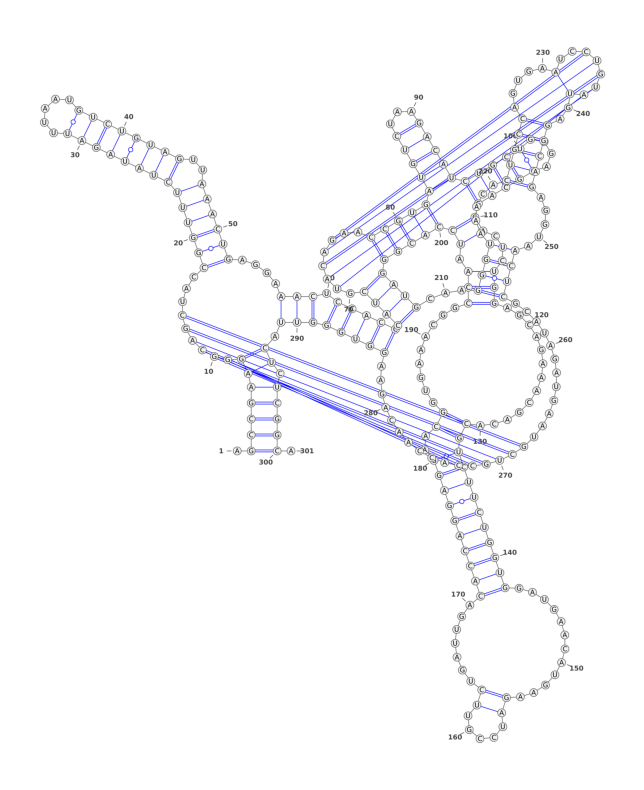

Printing default RNA .............................................................................................................................................................................................................................................................................................................
Output file: /home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/UFold/analysis/plots/RNaseP_ERH.png



In [16]:
dot2png(png_file_ref, ref_file.sequence, ref_file.structure, resolution=20)
show_varna_plot(png_file_ref)

dot2png(png_file, ref_file.sequence, db, resolution=20)
show_varna_plot(png_file)